Setup and GPU Check

In [1]:
import torch 

# Check if a CUDA-enabled GPU is available
print("CUDA available:", torch.cuda.is_available())

# Print number of GPUs available
print("Device count:", torch.cuda.device_count())

# If GPU exists, print its name
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Device count: 1
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
!pip install matplotlib # Install library for plotting graphs

DataLoader

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
from torch.utils.data import Subset

# Path to training images folder
train_dir = r"C:\Users\khali\Synoptic Project\dataset_balanced\train"
# Path to validation images folder
val_dir   = r"C:\Users\khali\Synoptic Project\dataset_split\val"
# Path to test images folder
test_dir  = r"C:\Users\khali\Synoptic Project\dataset_split\test"
# Set device to GPU if available otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Print which device is being used
print("Device:", device)

# Data Transforms
# Training image transformation
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),  # Resize all images to 300x300
    transforms.RandomHorizontalFlip(),  # Randomly flip images left-right
    transforms.RandomRotation(30),  # Randomly rotate image up to 30 degrees
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),  # Random crop 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Change brightness, contrast
    transforms.ToTensor(),  # Convert image to PyTorch tensor
    transforms.Normalize([0.485, 0.456, 0.406],  # Normalize mean 
                         [0.229, 0.224, 0.225])  # Normalize standard deviation
])

# Validation and test transformations
val_test_transform = transforms.Compose([
    transforms.Resize((300, 300)),  # Resize images
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406],  # Normalize using ImageNet stats
                         [0.229, 0.224, 0.225])
])
#Datasets
# Load training images from folder
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)

# Load validation images
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)

# Load test images
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)
subset_ratio = 0.5  # Use only 50% of training data

np.random.seed(42)  # Fix randomness for reproducibility

# Calculate number of samples to keep
subset_size = int(len(train_dataset) * subset_ratio)

# Randomly select indices
indices = np.random.choice(len(train_dataset), subset_size, replace=False)

# Create smaller dataset using selected indices
train_dataset = Subset(train_dataset, indices)

# Print class  
print("Classes:", train_dataset.dataset.class_to_idx)

Device: cuda
Classes: {'Barred_Spiral': 0, 'Elliptical': 1, 'Spiral': 2}


EfficientNet-B3 Model

In [7]:
num_classes = 3        # Set your number of classes
from torchvision.models import EfficientNet_B3_Weights# Pretrained weights
# Load pretrained EfficientNet-B3 model
weights = EfficientNet_B3_Weights.IMAGENET1K_V1
model = models.efficientnet_b3(weights=weights)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classifier layer to match your number of classes
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,# input features
    num_classes  # output classes
)

# Unfreeze last few convolution layers 
for param in model.features[-4:].parameters():
    param.requires_grad = True

# Make classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

# Loss function for classification problems
criterion = nn.CrossEntropyLoss()
# Optimizer Adam adjusts learning automatically

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),

)

Hyperparameter Search Function

In [14]:
def hpo_objective(BEST_LR, BEST_BATCH_SIZE, epochs=1):

 # Create training DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BEST_BATCH_SIZE, shuffle=True, num_workers=4)
        # Create validation DataLoader

    val_loader   = DataLoader(val_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False, num_workers=4)

    best_val_acc = 0.0  # store the highest validation accuracy achieved

    for epoch in range(epochs):
        # TRAIN
        model.train() # Set model to training mode
        correct_train, total_train = 0, 0 # Track accuracy
# Loop through training batches
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
              # Move data to GPU 
            images, labels = images.to(device), labels.to(device)
            # Reset gradients from previous step
            optimizer.zero_grad()
            #get model predictions
            outputs = model(images)
            # calculate loss
            loss = criterion(outputs, labels)
             # Backpropagation 
            loss.backward()
             # Update model weights
            optimizer.step()
            # Get predicted class
            _, predicted = torch.max(outputs, 1)
                # Count correct predictions
            correct_train += (predicted == labels).sum().item()
              # Count total samples
            total_train += labels.size(0)
        # calculate training accuracy for this epoch
        train_acc = correct_train / total_train

 # Set model to evaluation mode
        model.eval()
         # correct predictions on validation set
        correct_val, total_val = 0, 0 # total validation samples
# Disable gradient calculation 
        with torch.no_grad():
            for images, labels in val_loader:  # Loop through validation batches
                images, labels = images.to(device), labels.to(device) # Move data to GPU
                outputs = model(images)   # Forward pass only 
                _, predicted = torch.max(outputs, 1) # Get predicted class
                correct_val += (predicted == labels).sum().item()  # Count correct prediction
                total_val += labels.size(0)# Count total samples

        val_acc = correct_val / total_val# calculate validation accuracy
        best_val_acc = max(best_val_acc, val_acc) # Keep track of best validation accuracy seen so far

        print( # Print results for this epoch
            f"Epoch {epoch+1}: "
            f"Train Acc={train_acc*100:.2f}% | "
            f"Val Acc={val_acc*100:.2f}%"
        )

    return best_val_acc, train_acc# Return best validation accuracy and final training accuracy

Random Search HPO

In [15]:

class RandomSearcherEB3:
    def __init__(self, config_space, initial_config=None):
        self.config_space = config_space
        # Store the hyperparameter search space
        self.initial_config = initial_config
        #store a starting configuration
    def sample(self):
        if self.initial_config is not None:
             # If an initial configuration is given
            cfg = self.initial_config
             # Store it in a temporary variable
            self.initial_config = None
            # After using it once i remove it so it is NOT reused again
             # Return the initial configuration
             # If no initial config is left randomly sample new hyperparameters
            return cfg
             # For each hyperparameter (k)
            # use scipy.stats distribution (v) to randomly sample a value using .rvs()
        return {k: v.rvs() for k, v in self.config_space.items()}
         # Loop through all hyperparameters in the search space


In [16]:
import time
from scipy import stats
from tqdm import tqdm
# Store the best configuration 
best_config = None
# Store the best validation accuracy
best_val_acc = 0.0
# Number of different hyperparameter
num_trials = 10
# List to store results from all trials
results = []

for i in range(num_trials):
      # Generate a random configuration
    config = {
        # Learning rate sampled
        "BEST_LR": stats.loguniform(3e-5, 1e-4).rvs(),
         # Batch size sampled randomly between 16 and 31
        "BEST_BATCH_SIZE": stats.randint(16, 32).rvs(),  
    }
 # Print which trial is currently running and its hyperparameters
    print(f"\nTrial {i+1}/{num_trials} → {config}")
  # Start timer to measure training time
    start = time.time()
     # Train the model using the sampled hyperparameters
    val_acc, train_acc = hpo_objective(**config, epochs=5)
     # Calculate how long this trial took
    runtime = time.time() - start
 # Print performance of this trial
    print(
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Time: {runtime:.1f}s"
    )
# Store results of this trial in a list 
    results.append({
        "learning_rate": config["BEST_LR"],
        "batch_size": config["BEST_BATCH_SIZE"],
        "val_acc": val_acc
    })
  # Check if this model is better than previous best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config = config


Trial 1/10 → {'BEST_LR': 7.557930496927981e-05, 'BEST_BATCH_SIZE': 27}


Epoch 1/5: 100%|███████████████████████████████████████████████████████████████████| 3723/3723 [26:04<00:00,  2.38it/s]


Epoch 1: Train Acc=69.85% | Val Acc=71.41%


Epoch 2/5: 100%|███████████████████████████████████████████████████████████████████| 3723/3723 [26:27<00:00,  2.35it/s]


Epoch 2: Train Acc=73.15% | Val Acc=68.81%


...

Epoch 3: Train Acc=80.73% | Val Acc=75.24%


Epoch 4/5: 100%|███████████████████████| 3590/3590 [24:51<00:00,  2.41it/s]


Epoch 4: Train Acc=80.88% | Val Acc=74.38%


Epoch 5/5: 100%|█████████████████████████████████████████████████| 3590/3590 [24:19<00:00,  2.46it/s]


Epoch 5: Train Acc=81.01% | Val Acc=74.36%
Train Acc: 81.01% | Val Acc: 75.24% | Time: 9493.2s


Best Result

In [17]:
# Print a title so the output
print("BEST EFFICIENTNET-B3 HYPERPARAMETERS")
# Print the best configuration
print(best_config)
# Print the best validation accuracy achieved during hyperparameter search
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")


BEST EFFICIENTNET-B3 HYPERPARAMETERS
{'BEST_LR': 3.8485740671783625e-05, 'BEST_BATCH_SIZE': 28}
Best Validation Accuracy: 75.24%


HPO Visualization

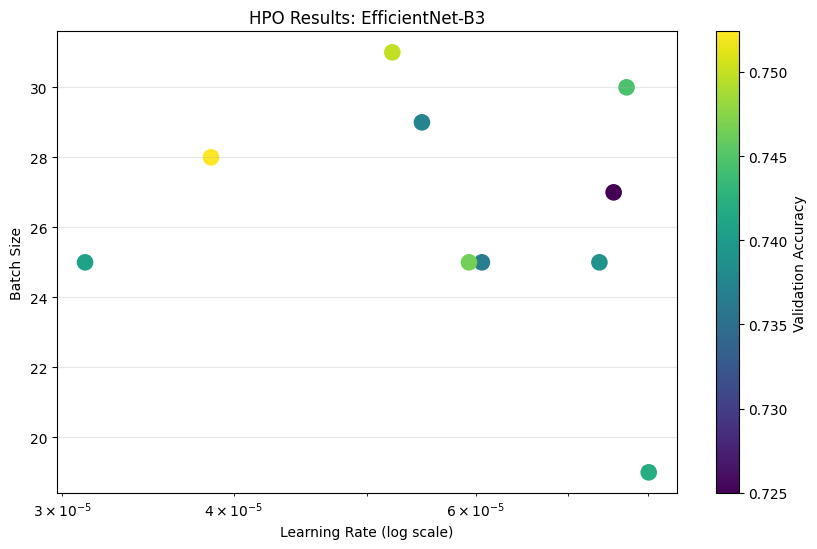

In [18]:
import matplotlib.pyplot as plt

# Get all learning rates from each trial resul
lrs = [r["learning_rate"] for r in results]
# Get all batch sizes from each trial result
batches = [r["batch_size"] for r in results]
# Get all batch sizes from each trial result
val_accs = [r["val_acc"] for r in results]
# Create a new figure with size 10x6 inches
plt.figure(figsize=(10, 6))
#Scatter plot 
# x-axis = learning rate
# y-axis = batch size
# color = validation accuracy
# cmap = color scheme viridis = blue to green to yellow
scatter = plt.scatter(
    lrs,
    batches,
    c=val_accs,
    cmap="viridis",
    s=120
)
# Use logarithmic scale for learning rate
plt.xscale("log")
# Add a color bar to show what colors mean
plt.colorbar(scatter, label="Validation Accuracy")
# Label x-axis
plt.xlabel("Learning Rate (log scale)")
# Label y-axis
plt.ylabel("Batch Size")
# Add title to plot
plt.title("HPO Results: EfficientNet-B3")
# Show grid lines for easier reading
plt.grid(True, alpha=0.3)
# Display the plot
plt.show()


Final Training

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import EfficientNet_B3_Weights
from tqdm import tqdm

# Best learning rate found from hyperparameter search
BEST_LR = best_config["BEST_LR"]
# Best batch size found from hyperparameter search
BEST_BATCH_SIZE = best_config["BEST_BATCH_SIZE"]
# Number of full passes through the dataset
EPOCHS = 50
# Choose device so GPU if available otherwise CPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  # Training data loader  
train_loader = DataLoader(train_dataset, batch_size=BEST_BATCH_SIZE, shuffle=True, num_workers=4)
# Validation data loader
val_loader   = DataLoader(val_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False, num_workers=4)
# Test data loader
test_loader  = DataLoader(test_dataset, batch_size=BEST_BATCH_SIZE, shuffle=False, num_workers=4)


#Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    for epoch in range(epochs):
  # Loop over each epoch

        model.train()# Set model to training mode
        running_loss = 0 # Track total training loss
        correct_train, total_train = 0, 0 # Track training accuracy
  # Loop through training batches
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)# Move data to GPU/CPU

            optimizer.zero_grad()# Reset gradients from previous step
            outputs = model(images) # Forward pass
            loss = criterion(outputs, labels)# calculate loss
            loss.backward()# Backpropagation
            optimizer.step()# Update model weights

            running_loss += loss.item()# Add batch loss to total
            _, preds = torch.max(outputs, 1)# Get predicted class
            correct_train += (preds == labels).sum().item()# Count correct predictions
            total_train += labels.size(0) # Count total samples
     # calculate training accuracy for this epoch
        train_acc = 100 * correct_train / total_train


        model.eval()# Set model to evaluation mode
        val_loss = 0# Track validation loss
        correct_val, total_val = 0, 0# Track validation accuracy

        with torch.no_grad():  # Disable gradient calculation
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"): # Loop through validation data
                images, labels = images.to(device), labels.to(device)  # Move data to device

                outputs = model(images)# Forward pass only
                loss = criterion(outputs, labels)# calculate validation loss
                val_loss += loss.item() # Accumulate loss

                _, preds = torch.max(outputs, 1)  # Get predicted class
                correct_val += (preds == labels).sum().item()  # Count correct predictions
                total_val += labels.size(0)# Count total samples
 # calculate validation accuracy
        val_acc = 100 * correct_val / total_val
        # print result
        print(
            f"\nEpoch {epoch+1}: "
            f"Train Loss={running_loss/len(train_loader):.4f}, Train Acc={train_acc:.2f}%, "
            f"Val Loss={val_loss/len(val_loader):.4f}, Val Acc={val_acc:.2f}%\n"
        ) 

# Train the Model

train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS)

NameError: name 'config' is not defined

Save Model

In [10]:
import torch
# Save the trained model's learned parameters
torch.save(model.state_dict(), "galaxy_modelEB3.pth")# state_dict() contains all the model's parameters after training
print("Model saved successfully!")# Print confirmation message 

Model saved successfully!


Training Curves

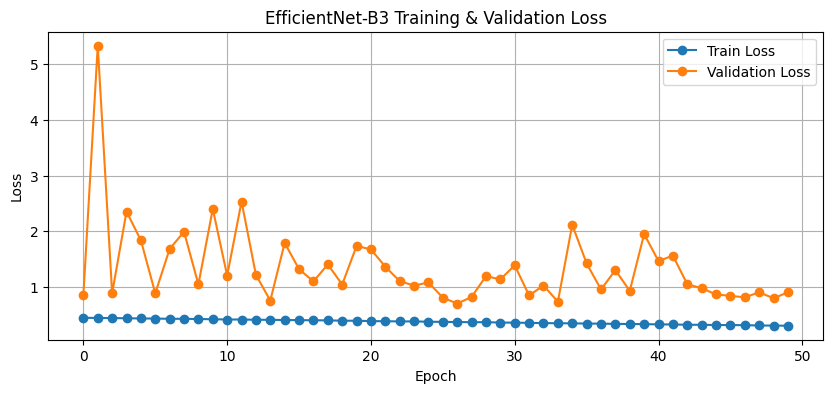

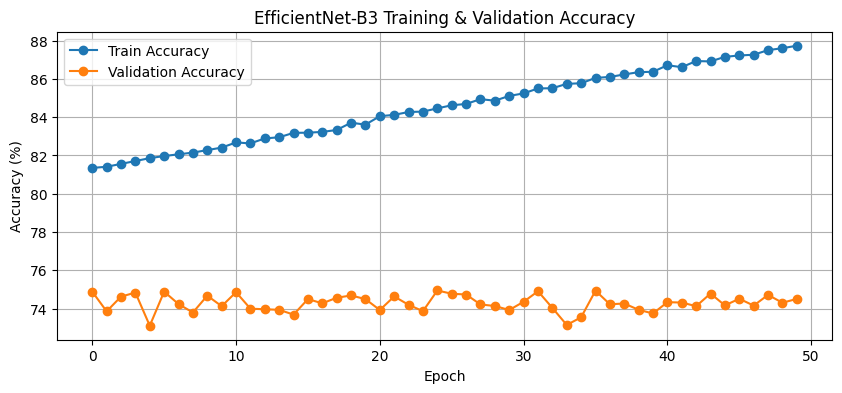

In [35]:
import matplotlib.pyplot as plt

# LOSS PLOT
# Create a new figure with size 10x4 inches
plt.figure(figsize=(10, 4))
# Plot Train loss over epochs
plt.plot(train_losses, label="Train Loss", marker='o')
# Plot Validation loss over epochs
plt.plot(val_losses, label="Validation Loss", marker='o')
# Set title of the graph
plt.title("EfficientNet-B3 Training & Validation Loss")
plt.xlabel("Epoch")# Label x-axis
plt.ylabel("Loss")# Label y-axis
plt.legend()# Label y-axis
plt.grid(True)# Add grid lines to make graph easier to read
plt.show()# Display the loss plot

# ----------------------------
# ACCURACY PLOT
# ----------------------------
plt.figure(figsize=(10, 4))
# Plot Train Accuracy over epochs
plt.plot(train_accs, label="Train Accuracy", marker='o')
# Plot Validation Accuracy over epochs
plt.plot(val_accs, label="Validation Accuracy", marker='o')
plt.title("EfficientNet-B3 Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

Evaluation

In [11]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\khali\torch_env\Scripts\python.exe -m pip install --upgrade pip' command.


In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, test_loader, device, class_names=None):
    model.eval()
    # Set model to evaluation mode
    all_preds = [] # Store all predicted labels
    all_labels = []  # Store all true labels

    with torch.no_grad(): # Disable gradient calculations
        for images, labels in test_loader:# Loop through test dataset batch by batch
            images, labels = images.to(device), labels.to(device)# Move data to GPU
            # Forward pass
            outputs = model(images)
            logits = outputs if not hasattr(outputs, "logits") else outputs.logits
            # Get predicted class
            _, preds = torch.max(logits, 1)
            # Store prediction
            all_preds.extend(preds.cpu().numpy())
             # Store true labels
            all_labels.extend(labels.cpu().numpy())
# Convert lists to NumPy arrays for easier calculations
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate overall accuracy
    acc = np.mean(all_preds == all_labels) * 100
    # Print accuracy
    print(f"Test Accuracy: {acc:.2f}%\n")
     # Print detailed classification report
    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds, digits=4))

    #Create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    ## Create figure for matrix
    plt.figure(figsize=(6, 5))
    # Show matrix as an image
    plt.imshow(cm)
   # Add title
    plt.title("EfficientNet-B3 Confusion Matrix")
   # Label axes
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # Add class names on axes if provided
    if class_names:
        plt.xticks(range(len(class_names)), class_names, rotation=45)
        plt.yticks(range(len(class_names)), class_names)

    # Add numbers inside squares
    for i in range(cm.shape[0]):# loop rows
        for j in range(cm.shape[1]):# loop column
            plt.text(j, i, cm[i, j], ha="center", va="center")#position, vertical, horizontal alignment and vertical alignment
# Add color bar
    plt.colorbar()
        # Adjust layout so labels fit
    plt.tight_layout()
    # Display the confusion matrix
    plt.show()

Test Accuracy: 73.07%

Classification Report:

              precision    recall  f1-score   support

           0     0.7691    0.6822    0.7230     12629
           1     0.7659    0.8206    0.7923     13616
           2     0.6671    0.6882    0.6775     14373

    accuracy                         0.7307     40618
   macro avg     0.7340    0.7303    0.7309     40618
weighted avg     0.7319    0.7307    0.7301     40618



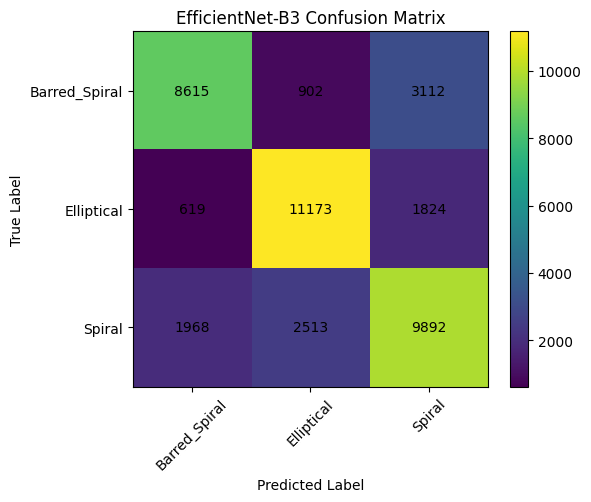

In [29]:
# Define the class names
class_names = ["Barred_Spiral", "Elliptical", "Spiral"]  # change to your dataset
# Call the evaluation function
# model is  your trained EfficientNet-B3 model
# test_loader is DataLoader containing test images
# deviceis= GPU or CPU
# class_names =is labels for each class 
evaluate_model(model, test_loader, device, class_names)

Grad-CAM

In [35]:
from torchcam.methods import SmoothGradCAMpp
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt

In [42]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


In [35]:
import numpy as np
import torch.nn.functional as F
# Define class names
class_names = ["Barred_Spiral", "Elliptical", "Spiral"]
# Set model to evaluation mode 
model.eval()


def generate_gradcam_effnet(image_tensor, target_class=None):
    model.eval() # Ensure model is in evaluation mode

    activations = []# Will store feature maps from forward pass
    gradients = [] # Will store gradients from backward pass

    # Choose the lasy convolutional block in EfficientNet-B
      # This is where Grad-CAM works best
    target_layer = model.features[-4]
 # Forward is to saves activations
    def forward_hook(module, input, output):
        activations.append(output)
    # Backward is to saves gradients 
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
 # Attach hooks to the target layer
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(image_tensor)# Get model prediction
  # If no class is specified use the predicted class
    if target_class is None:
        target_class = output.argmax(dim=1).item()

    model.zero_grad()# Clear previous gradients
    score = output[:, target_class]# Get score for target class
    score.backward()# Backpropagate to calculate gradients

    activation = activations[0]# Feature maps from forward 
    gradient = gradients[0]# Gradients from backward 
  # Global average pooling of gradients
    weights = gradient.mean(dim=(2, 3), keepdim=True)
        # Weighted combination of feature maps
    cam = (weights * activation).sum(dim=1, keepdim=True)
    cam = F.relu(cam) # Apply ReLU
# Remove extra dimensions
    cam = cam.squeeze().detach().cpu()# Move to CPU
    cam = cam / (cam.max() + 1e-8)# Normalize values between 0 and 1

    forward_handle.remove()# Remove forward 
    backward_handle.remove()# Remove  backward 

    return cam.numpy(), target_class  # Return heatmap and class index

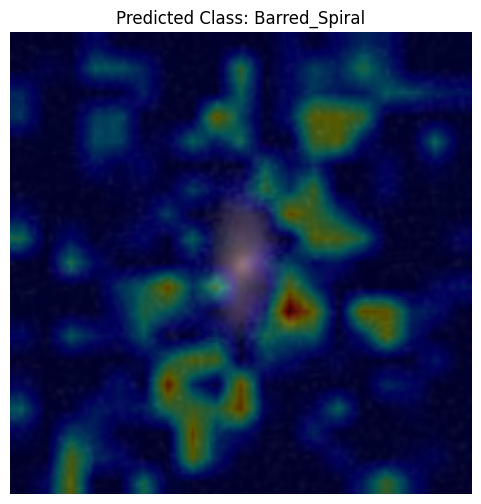

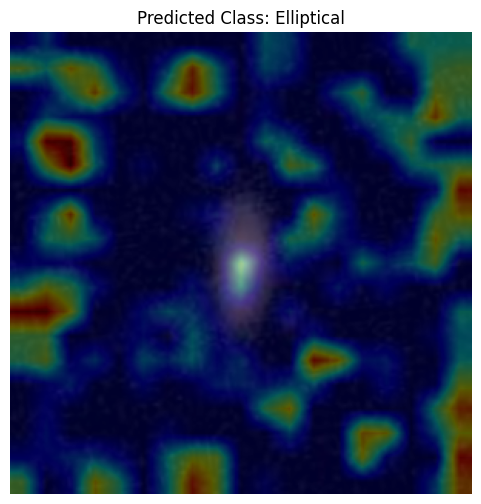

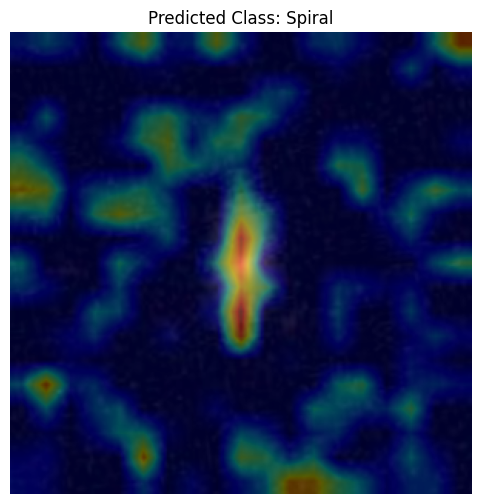

In [43]:
# Get one image and its label from validation dataset
image, label = val_loader.dataset[0]
# Add batch dimension and move to device so GPU/CPU
image = image.unsqueeze(0).to(device)
# Loop through each class
for class_idx, class_name in enumerate(class_names):
    heatmap, _ = generate_gradcam_effnet(image, target_class=class_idx)

    show_gradcam(    # Show image with heatmap
        image.squeeze(0),  # remove batch dimension
        heatmap,# Grad-CAM heatmap
        class_idx, # class index
        class_names # class labels
    )